# Rotifer-algae predator prey system

In this notebook, we show that Helmholtz-SDE learns the population dynamics between rotifers (_B. calyciflorus_), a freshwater zooplankton, and its prey, green algae. 
This dataset was obtained from

```
Blasius, B. et al., Long-term cyclic persistence in an experimental predator–prey system. Nature, 2020.
```

## Imports

In [1]:
# Generic imports
import jax
import jax.numpy as jnp
import jax.random as jr
from jax import vmap

import numpy as np
import pandas as pd
import os

from functools import partial

jax.config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt

In [2]:
# Imports from helmholtz_sde
from helmholtz_sde.utils.general_helpers import simulate_sde, simulate_learned_prior_samples
from helmholtz_sde.utils.plotting import plot_losses
from helmholtz_sde.helmholtz.subspace import LeastSquaresCorrection
from helmholtz_sde.sde import NeuralSDE, DriftNetwork, DiffusionNetwork
from helmholtz_sde.likelihood import Gaussian
from helmholtz_sde.posterior.encoder import NullEncoder, constant_ctx
from helmholtz_sde.posterior.grid_posterior import GridInferenceNetwork
from helmholtz_sde.posterior.drift import PosteriorSDE, simulate_posterior_samples
from helmholtz_sde.train import train
from helmholtz_sde.data import ProcessedData

In [3]:
# Imports for the wavelet analysis, the streamline plot and the shared experiment code
import sys
sys.path.append("..")
from experiment_utils import eval_correction
from blasius_wavelet_phase import blasius_phase_analysis
from scipy.integrate import odeint

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
# Plotting colors for each observed variable
var_colors = ["tab:blue", "tab:red"] # (algae, rotifers)
var_labels = ["log(Algae)", "log(Rotifers)"]

# Global seed for reproducibility
master_key = jr.PRNGKey(0)
key_init, key_output, key_train, _, key_prior, _, key_forecast, _, key_post_sde = jr.split(master_key, 9)

## Dataset preprocessing and visualization

We begin by loading and preprocessing the dataset obtained from Blasius et al., 2020. The dataset is subsetted to windows of coherent oscillation. 
This yields 255 observations across 4 subtrials. 
The most important preprocessing step involves log transforming the population counts.

In [6]:
data_dir = os.path.join("..", "datasets", "algae")
col_names = ["time", "algae", "rotifers", "egg_ratio", "eggs", "dead", "external_medium"]

# Load C1
df_c1 = pd.read_csv(os.path.join(data_dir, "C1.csv"), header=0, names=col_names)
print(f"C1: {len(df_c1)} rows, {int(df_c1.isna().any(axis=1).sum())} rows with NaN")

# Drop rows containing NaN in the algae or rotifers columns
df_c1 = df_c1.dropna(subset=["algae", "rotifers"]).reset_index(drop=True)
print(f"C1: {len(df_c1)} rows after dropping NaN")

C1: 366 rows, 8 rows with NaN
C1: 358 rows after dropping NaN


In [7]:
# Average and std log abundance for C1
log_algae = np.log(df_c1["algae"].values)
log_rotifers = np.log(df_c1["rotifers"].values)
print(f"C1: log(algae) mean={log_algae.mean():.3f} std={log_algae.std():.3f}, "
      f"log(rotifers) mean={log_rotifers.mean():.3f} std={log_rotifers.std():.3f}")

C1: log(algae) mean=-0.823 std=0.571, log(rotifers) mean=3.176 std=0.562


In [ ]:
# Extract algae and rotifers (D=2), log-transform and center by the pooled mean
D = 2 # observation dimension

# Coherent time windows for C1 (in original days)
c1_windows = [(19.5, 130.5), (159.5, 240.5), (274.5, 295.5), (314.5, 370.5)]

pooled_mean = np.log(df_c1[["algae", "rotifers"]].values).mean(axis=0) # (D)
print(f"Pooled log-mean: {pooled_mean}")

ys_list = [] # per-window centered log observations (all obs in the window)
ts_list = [] # per-window zero-referenced observation times (all obs in the window)
trial_names = [] # window labels

t_raw_full = df_c1["time"].values
y_full = np.log(df_c1[["algae", "rotifers"]].values) - pooled_mean

for w_idx, (t_start, t_end) in enumerate(c1_windows):
    mask = (t_raw_full >= t_start) & (t_raw_full <= t_end)
    if mask.sum() == 0:
        print(f" Warning: C1 window ({t_start}, {t_end}) has no observations, skipping")
        continue
    y_w = y_full[mask]
    t_raw_w = t_raw_full[mask]
    ys_list.append(y_w)
    ts_list.append(t_raw_w - t_raw_w[0]) # zero-referenced
    trial_names.append(f"C1_w{w_idx}")
    print(f"C1 window ({t_start:.0f}, {t_end:.0f}): {len(y_w)} obs, days {t_raw_w[0]:.1f}-{t_raw_w[-1]:.1f}")

n_trials = len(trial_names)
window_lengths = np.array([len(y) for y in ys_list]) # total obs per window (training + held-out)
print(f"\nn_trials: {n_trials}, window_lengths: {window_lengths}")

Pooled log-mean: [-0.82265732  3.17554212]
C1 window (20, 130): 111 obs, days 20.0-130.0
C1 window (160, 240): 75 obs, days 159.9-240.2
C1 window (274, 296): 20 obs, days 275.1-295.0
C1 window (314, 370): 49 obs, days 315.0-369.9

n_trials: 4, window_lengths: [111  75  20  49]


In [9]:
# Pad each full window (training + held-out) to a common length, then hold out the last holdout_n_obs observations of
# each window for forecasting (masked out of the likelihood)
holdout_n_obs = 8
T_max = int(window_lengths.max())

# Repeat-pad each full window to T_max
ys_padded = np.zeros((n_trials, T_max, D))
ts_padded = np.zeros((n_trials, T_max))
padding_mask = np.zeros((n_trials, T_max), dtype=bool)
for i in range(n_trials):
    L = window_lengths[i]
    ys_padded[i, :L], ts_padded[i, :L], padding_mask[i, :L] = ys_list[i], ts_list[i], True
    ys_padded[i, L:], ts_padded[i, L:] = ys_list[i][-1], ts_list[i][-1] # repeat the last observation and time

ys_all = jnp.array(ys_padded)
obs_times_all = jnp.array(ts_padded)
t_max = float(obs_times_all.max())
t_end_arr = obs_times_all[jnp.arange(n_trials), window_lengths - 1] # (n_trials) last observation time of each window

# Held-out mask: the last holdout_n_obs observations of each window (keeping at least one training observation)
holdout_mask = np.zeros((n_trials, T_max), dtype=bool)
for i in range(n_trials):
    L = window_lengths[i]
    holdout_mask[i, L - min(holdout_n_obs, L - 1):L] = True

# Training mask: 1 for training observations, 0 for held-out observations and padding
train_mask = padding_mask & ~holdout_mask
train_mask_arr = jnp.array(train_mask.astype(np.float64))

def overlay_obs(ax, i, j, train_style, held_style):
    """Overlays the training and held-out observations of coordinate j of window i"""
    L = window_lengths[i]
    train_idx, held_idx = np.flatnonzero(train_mask[i, :L]), np.flatnonzero(holdout_mask[i, :L])
    ax.plot(np.array(obs_times_all[i, train_idx]), np.array(ys_all[i, train_idx, j]), "o", label="Train", **train_style)
    if len(held_idx) > 0:
        ax.plot(np.array(obs_times_all[i, held_idx]), np.array(ys_all[i, held_idx, j]), "x", label="Held-out", **held_style)

print(f"ys_all.shape: {ys_all.shape}, T_max: {T_max}, t_max: {t_max:.4f}")
for i in range(n_trials):
    held_days = np.array(obs_times_all[i, holdout_mask[i]])
    print(f"{trial_names[i]}: {int(train_mask[i].sum())} training obs, {len(held_days)} held-out obs (days {held_days[0]:.1f}-{held_days[-1]:.1f})")

ys_all.shape: (4, 111, 2), T_max: 111, t_max: 109.9800
C1_w0: 103 training obs, 8 held-out obs (days 102.9-110.0)
C1_w1: 67 training obs, 8 held-out obs (days 72.2-80.3)
C1_w2: 12 training obs, 8 held-out obs (days 13.1-19.9)
C1_w3: 41 training obs, 8 held-out obs (days 47.9-54.9)


We visualize the log-transformed rotifer and algae populations for each window and mark the held-out observations.

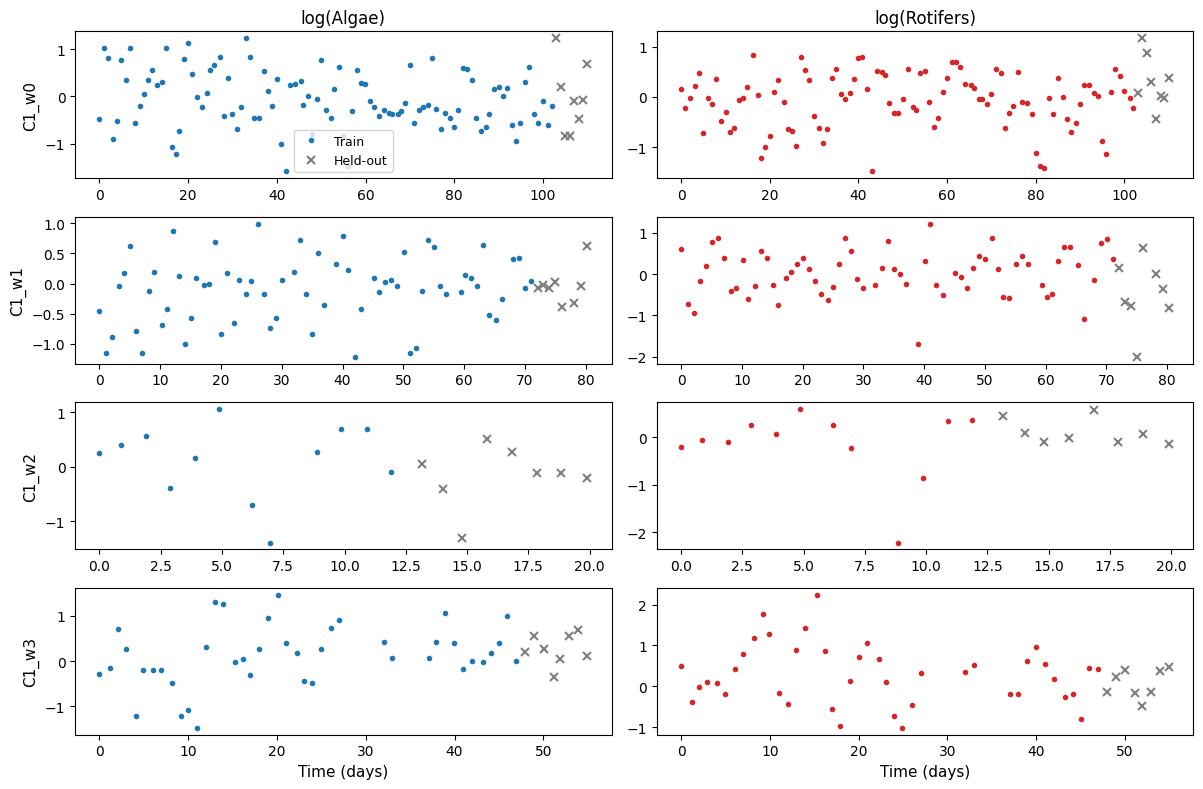

In [10]:
# Visualize the train/held-out split of each window
fig, axs = plt.subplots(n_trials, D, figsize=(6 * D, 2 * n_trials), squeeze=False)
for i in range(n_trials):
    for j in range(D):
        ax = axs[i, j]
        overlay_obs(ax, i, j, dict(color=var_colors[j], markersize=3), dict(color="0.5", markersize=6, mew=1.5))
        if j == 0:
            ax.set_ylabel(trial_names[i], fontsize=11)
        if i == 0:
            ax.set_title(var_labels[j], fontsize=12)
        if i == n_trials - 1:
            ax.set_xlabel("Time (days)", fontsize=11)
        if i == 0 and j == 0:
            ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

Finally, we compute the peak cyclic period and predator lag from the data according to the wavelet analysis from Blasius et al., 2020.

In [11]:
# Wavelet phase analysis of the raw C1 data (Blasius et al., 2020 methodology)
t_raw = df_c1["time"].values
algae_raw = df_c1["algae"].values # original space (not log-transformed)
rotifers_raw = df_c1["rotifers"].values

# Interpolate onto a regular daily grid (the wavelet transform requires uniform sampling)
wavelet_dt = 1.0 # days
t_regular = np.arange(t_raw[0], t_raw[-1], wavelet_dt)
samples_c1 = np.stack([np.interp(t_regular, t_raw, algae_raw), np.interp(t_regular, t_raw, rotifers_raw)], axis=-1)[None, :, :] # (1, T, 2)
print(f"C1 raw data: {len(t_raw)} obs over [{t_raw[0]:.0f}, {t_raw[-1]:.0f}] days, interpolated to {len(t_regular)} points at dt={wavelet_dt} day\n")

_ = blasius_phase_analysis(samples_c1, t_regular, noctave=3)

C1 raw data: 358 obs over [1, 374] days, interpolated to 373 points at dt=1.0 day

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Blasius et al., 2020 wavelet phase analysis of 1 samples with 373 points at dt = 1.0000 days (omega0 = 6.0, nvoices = 100, noctave = 3, WCO threshold = 0.83)


┌ Warning: CHOLMOD version incompatibility
│ 
│ Julia was compiled with CHOLMOD version 4.0.4. It is
│ currently linked with version 5.3.0.
│ This might cause Julia to terminate when working with
│ sparse matrix factorizations, e.g. solving systems of
│ equations with \.
│ 
│ It is recommended that you use Julia with the same major
│ version of CHOLMOD as the one used during the build, or
│ download the generic binaries from www.julialang.org,
│ which ship with the correct versions of all dependencies.
└ @ SparseArrays.CHOLMOD /home/groups/btrippe/henry/miniconda3/envs/helmholtz-sde/share/julia/stdlib/v1.10/SparseArrays/src/solvers/cholmod.jl:206


  sample 1/1: phase lag 89.9 deg, coherent fraction 71.6%
Peak period: 6.76 days
Phase lag: 89.9 +/- 0.0 deg (1/1 samples with coherent phases), i.e. 1.69 days
Rotational coherence: 71.6%
Blasius et al., 2020 report a phase lag of 93 +/- 21 deg and a period of 6.7 days


## Fitting Helmholtz-SDE

We are prepared to fit Helmholtz-SDE on the log-transformed rotifer and algae populations.

We choose latent dimension $K=2$, which is equal to the observation dimension. For our prior drift, we choose a shallow (one hidden layer) neural network. We use a linear Gaussian observation model:

\begin{align*}
\boldsymbol{y}(t_n) = \boldsymbol{C} \boldsymbol{x}(t_n) + \boldsymbol{d} + \boldsymbol{\varepsilon}(t_n), \quad \boldsymbol{\varepsilon}(t_n) \sim N(\boldsymbol{0}, \boldsymbol{R}),
\end{align*}

where $\boldsymbol{C} \in \mathbb{R}^{2 \times 2}$ and $\boldsymbol{d} \in \mathbb{R}^{2}$ define the affine output mapping and $\boldsymbol{R} \in \mathbb{R}^{2 \times 2}$ is the observation noise covariance; all three are learned.

In [12]:
learn_prior = True
learn_output = True
per_trial_posterior = True
div_free = LeastSquaresCorrection(ell=1, kappa=1, n_mc=1) # divergence-free correction
gauge = "sqrt" # choose the posterior reference drift from SDE Matching (Bartosh et al., 2025)
div_free_eval = eval_correction(div_free, n_nodes=4) # correction used when sampling the posterior SDE

In [ ]:
# KL integration bounds
kl_t0_arr = jnp.zeros(n_trials) # times are zero-referenced within each window
kl_t1_arr = t_end_arr
print(f"KL integration bounds (days): {np.array(kl_t1_arr)}")
process_data = lambda ys, obs_times, key: ProcessedData(ys=ys, obs_times=obs_times, mask=train_mask_arr, mask_kl0=train_mask_arr, kl_t0=kl_t0_arr, kl_t1=kl_t1_arr)

KL integration bounds (days): [109.98  80.26  19.9   54.94]


In [ ]:
# Posterior: one Gaussian process on a dense time grid per window
K = 2 # latent dimension
hidden_dim = 64

encoder = NullEncoder(value=0.)
process_ctx = constant_ctx
post_dt = 0.1
n_timesteps_post = int(t_max / post_dt)
post_net = GridInferenceNetwork(K, jnp.linspace(0., t_max, n_timesteps_post + 1))
print(f"Posterior: grid (dt={post_dt}, {n_timesteps_post + 1} points)")

Posterior: grid (dt=0.1, 1100 points)


In [15]:
drift_net = DriftNetwork(hidden_dim=hidden_dim, K=K, depth=1)
init_key_drift, init_key_diff = jr.split(key_init, 2)
network_params = drift_net.init(init_key_drift, jnp.zeros((K,)), jnp.zeros((1,)))

if div_free is not None or gauge == "sym": # the correction and the sym gauge require a state-independent diffusion coefficient, fixed to the identity
    sde_params = {"network_params_drift": network_params, "network_params_diffusion": None}
    prior = NeuralSDE(K, apply_fn_drift=drift_net.apply)
else: # learn a state-dependent diffusion coefficient (Bartosh et al., 2025)
    diff_net = DiffusionNetwork(hidden_dim=hidden_dim, K=K, depth=1, include_time=False)
    sde_params = {"network_params_drift": network_params, "network_params_diffusion": diff_net.init(init_key_diff, jnp.zeros((K,)), jnp.zeros((1,)))}
    prior = NeuralSDE(K, apply_fn_drift=drift_net.apply, apply_fn_diffusion=diff_net.apply, div_GGt_apply_fn=lambda params, x, t: diff_net.apply(params, x, t, method=DiffusionNetwork.div_GGt))

init_params = {"mu0": jnp.zeros((K)), "V0": jnp.eye(K)}

In [16]:
obs_var_init = 0.3 # initial observation noise variance (learned)
C_init_key, d_init_key = jr.split(key_output, 2)
output_params_init = {"C": jr.normal(key=C_init_key, shape=(D, K)), "d": jr.normal(key=d_init_key, shape=(D,)), "R": obs_var_init * jnp.eye(D)}
likelihood = Gaussian()

In [17]:
n_iters = 30000

params, metrics = train(
    key_train,
    ys_all,
    obs_times_all,
    likelihood,
    output_params_init,
    t_max,
    encoder,
    process_ctx,
    post_net,
    prior,
    sde_params,
    init_params,
    learning_rate_init=1e-2,
    learning_rate_final=1e-3,
    mc_samples=10000,
    jitter=1e-8,
    n_iters=n_iters,
    div_free=div_free,
    learn_prior=learn_prior,
    learn_output=learn_output,
    gauge=gauge,
    grad_clip_norm=5.0,
    process_data=process_data,
    kl_anneal_iters=0,
    per_trial_posterior=per_trial_posterior,
)

100%|██████████| 30000/30000 [09:57<00:00, 50.20it/s, kl=72.1, kl_w=1, loss=65.9, prior=0.815, rec=-7.05] 


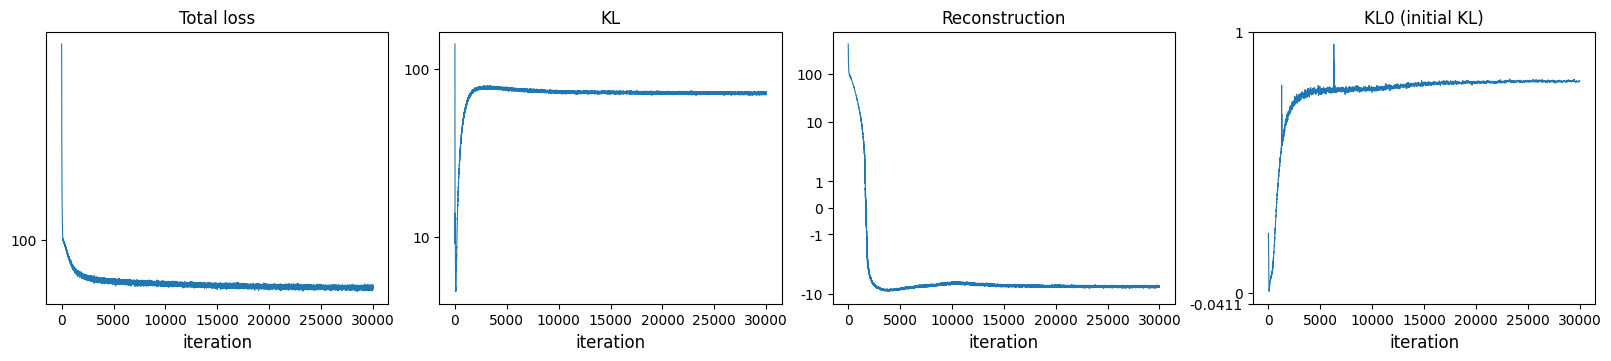

In [18]:
# Training loss curves
fig, axs = plot_losses(metrics)
plt.show()

## Visualization and evaluation of results

We first visualize the posterior mean and $\pm2$ posterior standard deviations.

In [ ]:
ctx_seqs = vmap(lambda y_i, m_i: encoder.apply(params["encoder_params"], y_i, m_i))(ys_all, train_mask_arr)
decode = lambda x: params["output_params"]["C"] @ x + params["output_params"]["d"] # latent -> observation space
post_params_for = lambda i: jax.tree.map(lambda x: x[i], params["posterior_params"]) if per_trial_posterior else params["posterior_params"]
proc_ctx_for = lambda i: partial(process_ctx, obs_times_all[i], mask=train_mask_arr[i])

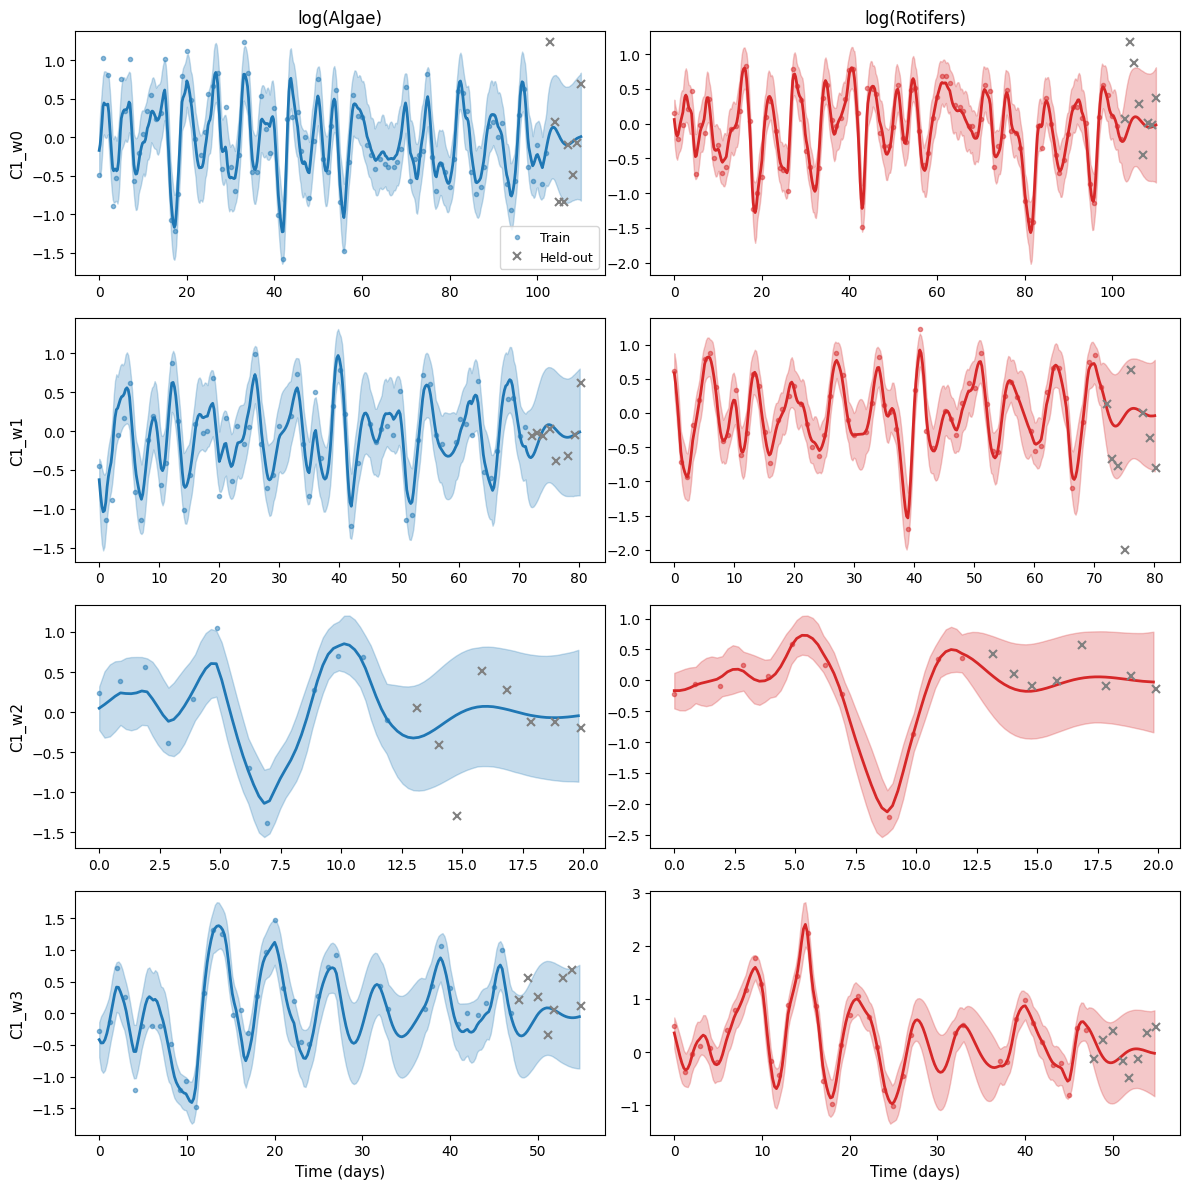

In [ ]:
# Posterior marginals in observation space via the linear decoder (analytic pushforward)
n_eval_timesteps = 500
ts_eval = jnp.linspace(0.0, t_max, n_eval_timesteps + 1)

def _obs_stats(i, t):
    """Mean and standard deviation of the posterior of window i at time t, mapped through the linear decoder"""
    m, R = post_net.apply(post_params_for(i), jnp.array([t], dtype=ys_all.dtype), ctx_seqs[i], proc_ctx_for(i))
    return decode(m), jnp.sqrt(jnp.sum((params["output_params"]["C"] @ R) ** 2, axis=-1)) # sqrt of diag(C S C^T) with S = R R^T

ms_obs, stds_obs = zip(*[vmap(lambda t: _obs_stats(i, t))(ts_eval) for i in range(n_trials)])
ms_obs, stds_obs = jnp.stack(ms_obs), jnp.stack(stds_obs) # (n_trials, T_eval, D)

# Plot the posterior marginals over each full window, with the train/held-out overlay
num_std = 2.0
fig, axs = plt.subplots(n_trials, D, figsize=(6 * D, 3 * n_trials), squeeze=False)
for i in range(n_trials):
    valid_eval = np.array(ts_eval) <= float(t_end_arr[i])
    for j in range(D):
        ax = axs[i, j]
        ts_plot, mu, sd = np.array(ts_eval)[valid_eval], np.array(ms_obs[i, :, j])[valid_eval], np.array(stds_obs[i, :, j])[valid_eval]
        ax.plot(ts_plot, mu, linewidth=2.0, color=var_colors[j])
        ax.fill_between(ts_plot, mu - num_std * sd, mu + num_std * sd, alpha=0.25, color=var_colors[j])
        overlay_obs(ax, i, j, dict(color=var_colors[j], markersize=3, alpha=0.5), dict(color="0.5", markersize=6, mew=1.5))
        if j == 0:
            ax.set_ylabel(trial_names[i], fontsize=11)
        if i == 0:
            ax.set_title(var_labels[j], fontsize=12)
        if i == n_trials - 1:
            ax.set_xlabel("Time (days)", fontsize=11)
        if i == 0 and j == 0:
            ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

The posterior mean closely tracks the observations. 
For this dataset, there is high posterior uncertainty in the log rotifer and algae populations. 

We next draw samples from the learned prior SDE. 
We map these samples into the observation space.

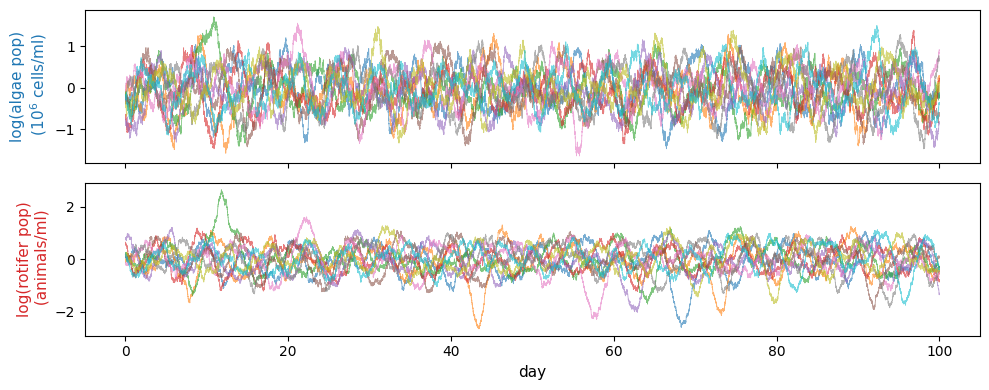

In [21]:
# Draw samples from the learned prior SDE and map them to observation space
n_prior_samples = 1024
n_sim_timesteps = 50000
t_max_sim = 100.0
xs_prior = simulate_learned_prior_samples(key_prior, prior, params, t_max=t_max_sim, n_timesteps=n_sim_timesteps, n_eval=n_prior_samples) # (n_prior_samples, n_sim_timesteps + 1, K)
ys_prior = vmap(vmap(decode))(xs_prior)
t_grid_sim = np.linspace(0.0, t_max_sim, n_sim_timesteps + 1)

# Plot a few prior samples
n_plot = 10
fig, axs = plt.subplots(D, 1, figsize=(10, 4), sharex=True)
for j, ylabel in enumerate(["log(algae pop)\n ($10^6$ cells/ml)", "log(rotifer pop)\n (animals/ml)"]):
    for s in range(n_plot):
        axs[j].plot(t_grid_sim, np.array(ys_prior[s, :, j]), linewidth=0.6, alpha=0.6, color=f"C{s}")
    axs[j].set_ylabel(ylabel, color=var_colors[j], fontsize=11)
axs[1].set_xlabel("day", fontsize=11)
plt.tight_layout()
plt.show()

From the samples, we observe persistent oscillations where the rotifer population lags that of the algae. 
We examine this further by plotting the learned prior dynamics, again in the observation space.

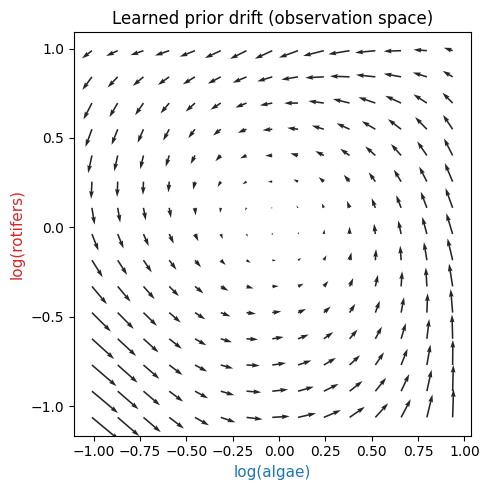

In [22]:
# Learned prior drift in observation space: for the linear decoder y = Cx + d, dy/dt = C f(C^{-1}(y - d))
n_grid_2d = 15
C, d = params["output_params"]["C"], params["output_params"]["d"] # (D, K), (D)
C_inv = jnp.linalg.inv(C)
t_dummy = jnp.zeros((1,)) # the drift is time-homogeneous

def pushforward_drift(y):
    return C @ prior.drift(C_inv @ (y - d), t_dummy, params["sde_params"])

# Grid extent from the prior samples
ys_flat = np.array(ys_prior[:, ::200, :]).reshape(-1, D)
lo, hi = np.percentile(ys_flat, 5, axis=0), np.percentile(ys_flat, 95, axis=0)
lo, hi = lo - 0.1 * (hi - lo), hi + 0.1 * (hi - lo)
G1, G2 = jnp.meshgrid(jnp.linspace(lo[0], hi[0], n_grid_2d), jnp.linspace(lo[1], hi[1], n_grid_2d), indexing="ij")
grid_obs = jnp.stack([G1.ravel(), G2.ravel()], axis=-1) # (N, 2) in observation space
drift_obs = np.array(vmap(pushforward_drift)(grid_obs)) # (N, 2)

fig, ax = plt.subplots(figsize=(5, 5))
ax.quiver(np.array(G1), np.array(G2), drift_obs[:, 0].reshape(n_grid_2d, n_grid_2d), drift_obs[:, 1].reshape(n_grid_2d, n_grid_2d), angles="xy", scale_units="xy", alpha=0.85)
ax.set_xlabel("log(algae)", fontsize=11, color=var_colors[0])
ax.set_ylabel("log(rotifers)", fontsize=11, color=var_colors[1])
ax.set_title("Learned prior drift (observation space)", fontsize=12)
fig.tight_layout()
plt.show()

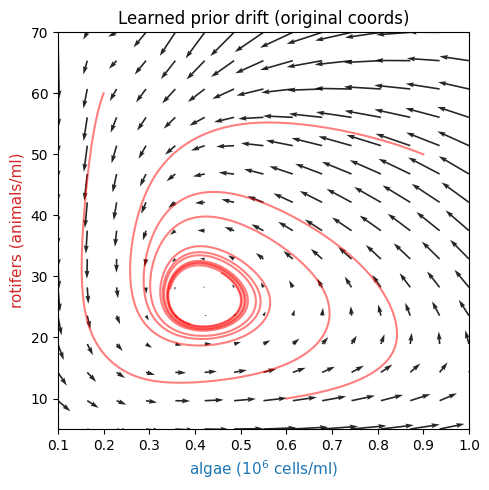

In [ ]:
# Learned prior drift in the original coordinates
lo, hi = (0.1, 5.0), (1.0, 70.0)
G1, G2 = jnp.meshgrid(jnp.linspace(lo[0], hi[0], n_grid_2d), jnp.linspace(lo[1], hi[1], n_grid_2d), indexing="ij")
grid_orig = jnp.stack([G1.ravel(), G2.ravel()], axis=-1)
pooled_mean_jnp = jnp.array(pooled_mean)

def pushforward_drift_original(y_orig):
    x = C_inv @ (jnp.log(y_orig) - pooled_mean_jnp - d) # original -> centered log -> latent space
    f_log = C @ prior.drift(x, t_dummy, params["sde_params"]) # drift in the centered log space
    G_x = prior.diffusion(x, t_dummy, params["sde_params"])
    ito_corr = 0.5 * jnp.diag(C @ G_x @ G_x.T @ C.T) # Ito correction of the exponential map
    return y_orig * (f_log + ito_corr) # Ito's lemma: dy/dt = y (f_log + ito_corr)

drift_orig = np.array(vmap(pushforward_drift_original)(grid_orig))

fig, ax = plt.subplots(figsize=(5, 5))
ax.quiver(np.array(G1), np.array(G2), drift_orig[:, 0].reshape(n_grid_2d, n_grid_2d), drift_orig[:, 1].reshape(n_grid_2d, n_grid_2d), angles="xy", scale_units="xy", scale=10.0, alpha=0.85)
t_ode = np.linspace(0, 20.0, 1000) # days
for y0 in [(0.2, 60), (0.6, 10), (0.9, 50)]: # streamlines from a few starting points
    traj = odeint(lambda y, t: np.array(pushforward_drift_original(jnp.array(y))), y0, t_ode)
    ax.plot(traj[:, 0], traj[:, 1], "r-", alpha=0.5, linewidth=1.5)
ax.set_xlim(lo[0], hi[0])
ax.set_ylim(lo[1], hi[1])
ax.set_xlabel(r"algae ($10^6$ cells/ml)", fontsize=11, color=var_colors[0])
ax.set_ylabel("rotifers (animals/ml)", fontsize=11, color=var_colors[1])
ax.set_title("Learned prior drift (original coords)", fontsize=12)
fig.tight_layout()
plt.show()

We find that the learned prior dynamics possess a limit cycle, which reflects the persistent cycle in the rotifer and algae populations.

Next, we compute and plot the forecasting predictions obtained from the learned dynamics.

In [24]:
# Forecasting from the last training observation of each window: sample the posterior at the anchor time and simulate the
# learned prior forward to the last held-out time
n_forecast_samples = 128

def forecast_window(key, i, n_samples):
    """Forecast samples (n_samples, n_steps + 1, D) of window i in observation space on a grid from the anchor time to the last held-out time"""
    L = window_lengths[i]
    t_anchor = float(obs_times_all[i, np.flatnonzero(train_mask[i, :L])[-1]]) # last training observation
    horizon = float(t_end_arr[i] - t_anchor)
    n_steps = max(int(horizon * 1000), 1)
    mt, Rt = post_net.apply(post_params_for(i), jnp.array([t_anchor], dtype=ys_all.dtype), ctx_seqs[i], proc_ctx_for(i)) # posterior marginal at the anchor
    key_init, key_sim = jr.split(key)
    x0 = mt[None, :] + jr.normal(key_init, shape=(n_samples, K), dtype=mt.dtype) @ Rt.T
    xs_fore = vmap(partial(simulate_sde, sde=prior, sde_params=params["sde_params"], t_max=horizon, n_timesteps=n_steps))(jr.split(key_sim, n_samples), x0)
    return t_anchor, np.linspace(t_anchor, t_anchor + horizon, n_steps + 1), vmap(vmap(decode))(xs_fore)

forecast_results = []
for i in range(n_trials):
    held_idx = np.flatnonzero(holdout_mask[i, :window_lengths[i]])
    if len(held_idx) == 0:
        continue
    t_anchor, t_grid_fore, ys_fore = forecast_window(jr.fold_in(key_forecast, i), i, n_forecast_samples)
    ts_ho, ys_ho = np.array(obs_times_all[i, held_idx]), np.array(ys_all[i, held_idx])
    idx_ho = np.clip(np.round((ts_ho - t_anchor) / (t_grid_fore[1] - t_grid_fore[0])).astype(int), 0, len(t_grid_fore) - 1) # forecast grid indices of the held-out times
    ys_pred = np.array(ys_fore[:, idx_ho]) # (n_forecast_samples, n_held, D)
    mean_sqerr = np.sum((ys_ho - ys_pred.mean(axis=0)) ** 2, axis=-1) # (n_held), error of the predictive mean
    pred_sqerr = np.mean(np.sum((ys_ho[None] - ys_pred) ** 2, axis=-1), axis=0) # (n_held), expected error under the predictive distribution
    forecast_results.append({"trial": trial_names[i], "n_held": len(held_idx), "t_anchor": t_anchor, "t_grid": t_grid_fore, "ys_fore": ys_fore, "mean_mse": float(mean_sqerr.mean()), "pred_mse": float(pred_sqerr.mean())})

print(f"Forecasting MSE in log coordinates (holdout_n_obs={holdout_n_obs}):\n")
print(f"{'Trial':<15} {'n_held':>6} {'Mean MSE':>10} {'Pred MSE':>10}")
print("-" * 44)
for r in forecast_results:
    print(f"{r['trial']:<15} {r['n_held']:>6} {r['mean_mse']:>10.4f} {r['pred_mse']:>10.4f}")
print("-" * 44)
print(f"{'Aggregate':<15} {'':>6} {np.mean([r['mean_mse'] for r in forecast_results]):>10.4f} {np.mean([r['pred_mse'] for r in forecast_results]):>10.4f}")

Forecasting MSE in log coordinates (holdout_n_obs=8):

Trial           n_held   Mean MSE   Pred MSE
--------------------------------------------
C1_w0                8     0.7339     1.1173
C1_w1                8     0.7637     1.1864
C1_w2                8     0.3182     0.7689
C1_w3                8     0.4771     0.8841
--------------------------------------------
Aggregate                  0.5732     0.9892


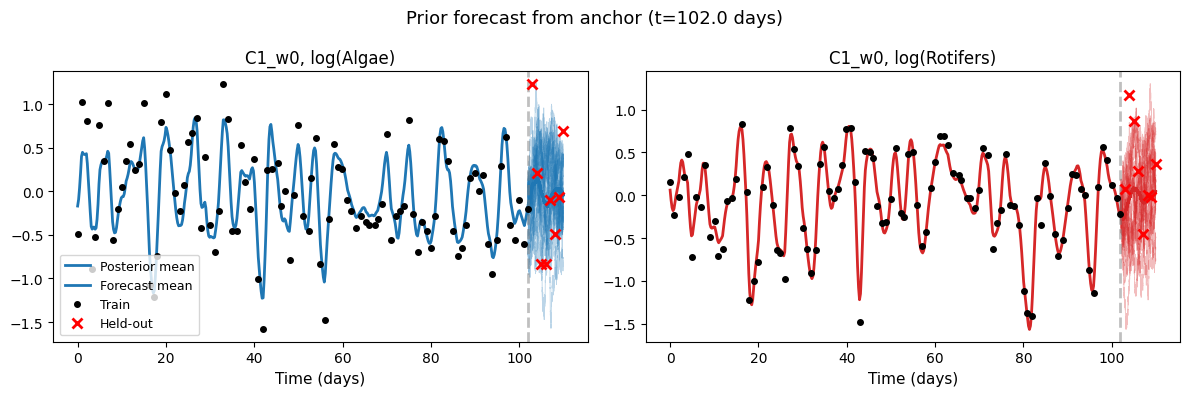

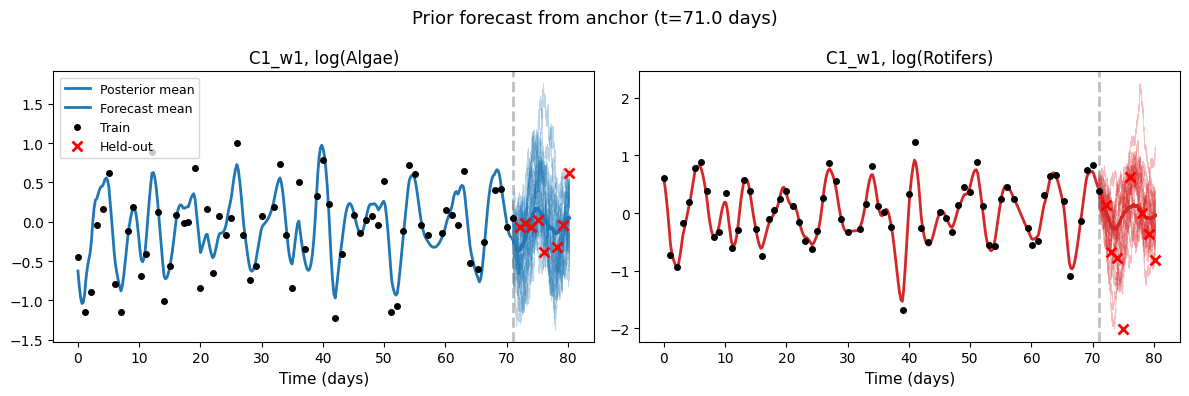

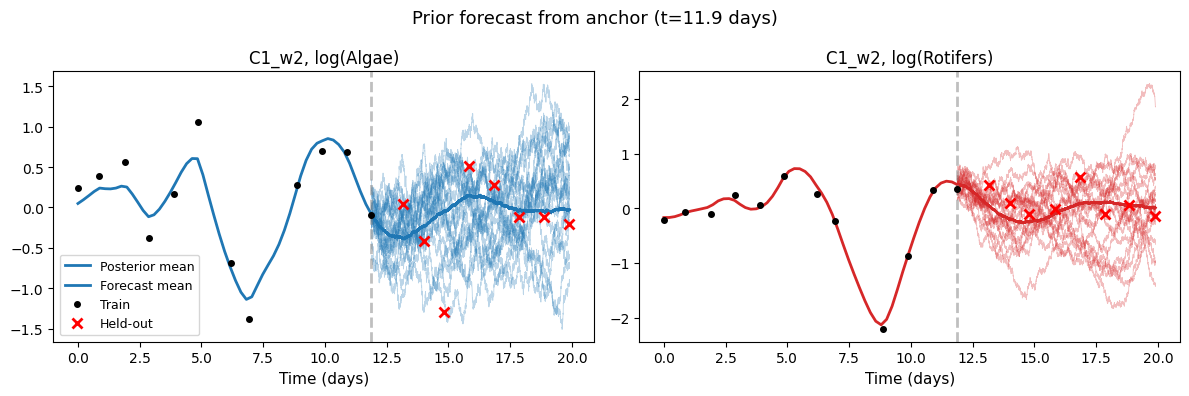

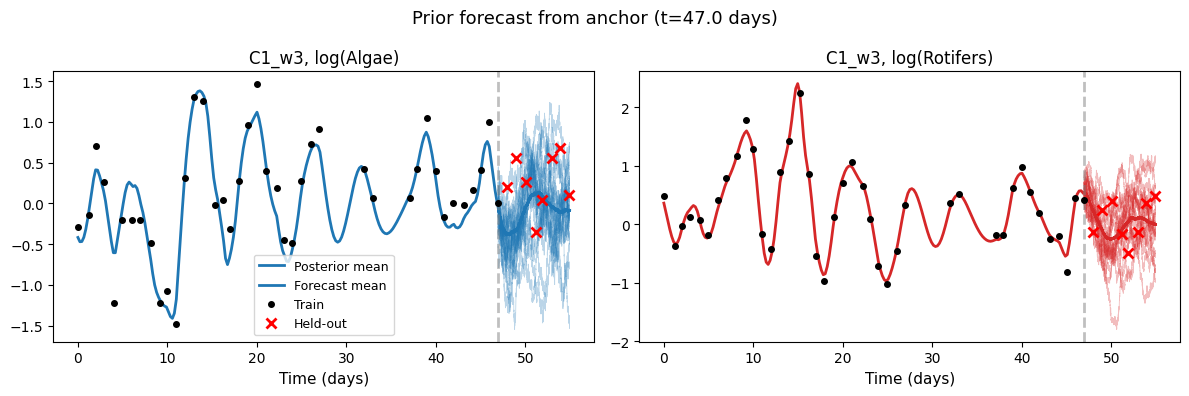

In [ ]:
# Plot the forecast samples against the held-out observations
n_show = 20
for r, i in zip(forecast_results, [i for i in range(n_trials) if holdout_mask[i].any()]):
    context = np.array(ts_eval) <= r["t_anchor"]
    fig, axs = plt.subplots(1, D, figsize=(6 * D, 4), squeeze=False)
    for j in range(D):
        ax = axs[0, j]
        ax.plot(np.array(ts_eval)[context], np.array(ms_obs[i, :, j])[context], color=var_colors[j], linewidth=2.0, label="Posterior mean")
        for s in range(n_show):
            ax.plot(r["t_grid"], np.array(r["ys_fore"][s, :, j]), linewidth=0.6, alpha=0.3, color=var_colors[j])
        ax.plot(r["t_grid"], np.array(r["ys_fore"].mean(axis=0)[:, j]), color=var_colors[j], linewidth=2.0, label="Forecast mean")
        overlay_obs(ax, i, j, dict(color="k", markersize=4, zorder=5), dict(color="red", markersize=7, mew=2, zorder=5))
        ax.axvline(r["t_anchor"], color="0.5", linestyle="--", linewidth=2, alpha=0.5)
        ax.set_title(f"{r['trial']}, {var_labels[j]}", fontsize=12)
        ax.set_xlabel("Time (days)", fontsize=11)
        if j == 0:
            ax.legend(fontsize=9)
    fig.suptitle(f"Prior forecast from anchor (t={r['t_anchor']:.1f} days)", fontsize=13)
    fig.tight_layout()
    plt.show()

Although the learned prior dynamics produce plausible forecast trajectories, these trajectories also have large marginal standard deviation. 
This reflects high stochasticity in the learned dynamics.

Next, we draw samples from the inferred posterior SDE.

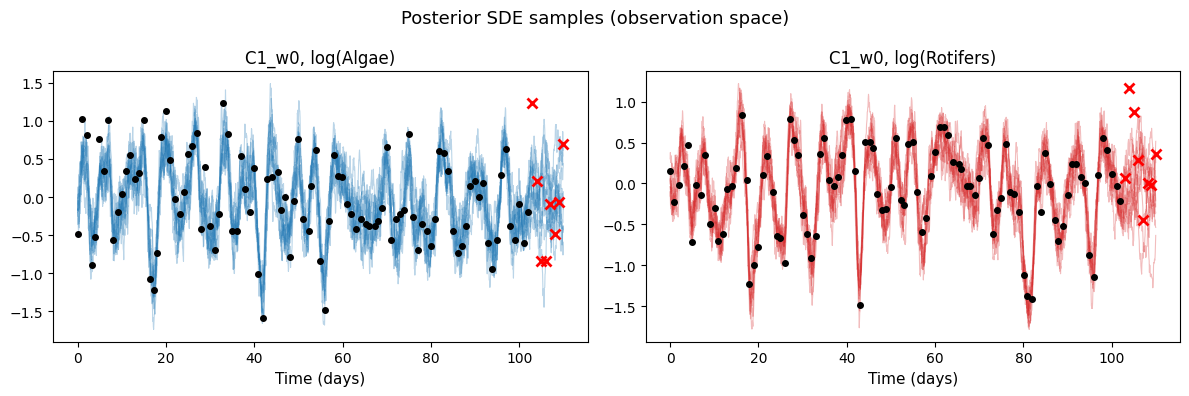

In [26]:
# Draw posterior samples for a window and plot them in observation space
window_idx = 0 # which window to sample from
n_post_samples = 64
n_post_timesteps = 2000

t_end_post = float(t_end_arr[window_idx]) # last observation time of the window

posterior_sde = PosteriorSDE(prior, post_net, ctx_seqs[window_idx], proc_ctx_for(window_idx), gauge=gauge, div_free=div_free_eval)
xs_post = simulate_posterior_samples(key_post_sde, posterior_sde, {**params, "posterior_params": post_params_for(window_idx)}, t_max=t_end_post, n_timesteps=n_post_timesteps, n_samples=n_post_samples)
ys_post = vmap(vmap(decode))(xs_post) # (n_post_samples, n_post_timesteps + 1, D)
t_grid_samples = np.linspace(0.0, t_end_post, n_post_timesteps + 1)

n_plot_post = 10
fig, axs = plt.subplots(1, D, figsize=(6 * D, 4), squeeze=False)
for j in range(D):
    ax = axs[0, j]
    for s in range(n_plot_post):
        ax.plot(t_grid_samples, np.array(ys_post[s, :, j]), linewidth=0.8, alpha=0.3, color=var_colors[j])
    overlay_obs(ax, window_idx, j, dict(color="k", markersize=4, zorder=5), dict(color="red", markersize=7, mew=2, zorder=5))
    ax.set_title(f"{trial_names[window_idx]}, {var_labels[j]}", fontsize=12)
    ax.set_xlabel("Time (days)", fontsize=11)
fig.suptitle("Posterior SDE samples (observation space)", fontsize=13)
fig.tight_layout()
plt.show()

Finally, we compute the period of the cyclic dynamics as well as the predator lag using the samples from our learned prior. 
We perform the same wavelet analysis as in Blasius et al., 2020. 

In [ ]:
# Downsample the prior samples to daily resolution, map them back to abundances, and run the wavelet analysis
step = max(1, round(wavelet_dt / (t_grid_sim[1] - t_grid_sim[0])))
ys_prior_orig = np.exp(np.array(ys_prior) + pooled_mean)
results = blasius_phase_analysis(ys_prior_orig[:, ::step, :], t_grid_sim[::step], noctave=3)

Blasius et al., 2020 wavelet phase analysis of 1024 samples with 101 points at dt = 1.0000 days (omega0 = 6.0, nvoices = 100, noctave = 3, WCO threshold = 0.83)
  sample 102/1024: phase lag 90.7 deg, coherent fraction 73.3%
  sample 204/1024: phase lag 97.3 deg, coherent fraction 78.2%
  sample 306/1024: phase lag 96.9 deg, coherent fraction 72.3%
  sample 408/1024: phase lag 88.0 deg, coherent fraction 78.2%
  sample 510/1024: phase lag nan deg, coherent fraction 0.0%
  sample 612/1024: phase lag 111.8 deg, coherent fraction 77.2%
  sample 714/1024: phase lag 93.8 deg, coherent fraction 63.4%
  sample 816/1024: phase lag 85.7 deg, coherent fraction 57.4%
  sample 918/1024: phase lag 92.7 deg, coherent fraction 56.4%
  sample 1020/1024: phase lag 94.0 deg, coherent fraction 83.2%
Peak period: 6.93 days
Phase lag: 88.9 +/- 9.8 deg (994/1024 samples with coherent phases), i.e. 1.71 days
Rotational coherence: 71.3%
Blasius et al., 2020 report a phase lag of 93 +/- 21 deg and a period of 6

The peak cyclic period and phase lag of the learned dynamics are 6.9 days and $89 \degree$, respectively. 
These statistics are close to the measurements $6.7$ days and $93 \degree$ reported by Blasius et al., 2020.